<h3/>
<h1 align="center">Universidad de Buenos Aires (FIUBA)</h1>
<h2 align="center">Especialización en Inteligencia Artificial - CEIA - FIUBA</h2>
<h2 align="center">Aprendizaje de Máquina I</h2>
<h3 align="center">Predicción de la recaudación de una película</h3>

<p align="left">
Integrantes:
  <ul>
    <li> Luis Jose Paredes Ramirez </li>
    <li> Hernando Scheidl </li>
    <li> Nicolás Lastra </li>
    <li> Diego Vazquez </li>
  <ul/>
</p>

---

# Planteo del problema y Fuente de datos

### Fuente de los datos

[Full TMDB Movies Dataset 2024 (1M Movies)](https://www.kaggle.com/datasets/asaniczka/tmdb-movies-dataset-2023-930k-movies) es un dataset publicado por [asaniczka](https://www.kaggle.com/asaniczka) en Kaggle.

Este dataset contiene informacion sobre peliculas extraidas a partir de la API pública de [The Movie Database (TMDB)](https://developer.themoviedb.org/docs/getting-started).


### Contexto del negocio

La mayoria de las peliculas producidas por la industria del cine no tienen exito financiero. Las grandes productoras suelen apostarle fuerte a los **blockbusters** con la esperanza de que estos recauden suficiente dinero para compensar las demas peliculas.

Coloquialmente se sigue una regla de oro informal:

> Una película financieramente exitosa recauda entre dos y tres veces su presupuesto. Es decir `revenue = k * budget`

### Planteo del Problema

En el siguiente trabajo practico se desarrollan distintos modelos de aprendizaje automatico con el objetivo de estimar la **recaudación mundial en dólares (`revenue`)** de una película a partir de sus características.

Se plantea un problema de **regresión** con una variable objetivo (`revenue`) continua, positiva y extremadamente asimétrica por naturaleza.

De entrada utilizaremos la regla de oro informal como baseline y se comparará contra los distintos modelos entrenados.

---
## 1. Descarga del dataset

In [ ]:
!pip install -q kagglehub optuna xgboost scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 22.7 MB/s eta 0:00:00


Importamos todas las librerias necesarias.

In [ ]:
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
from kagglehub import KaggleDatasetAdapter
from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import (GridSearchCV, KFold, cross_val_score, learning_curve, train_test_split)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor, plot_tree
from xgboost import XGBRegressor


Descargamos el archivo usando el SDK de [`kagglehub`](https://pypi.org/project/kagglehub/). Recordar que `file_path` apunta al nombre del archivo que se descarga.

Establecemos ciertos parametros para utilizarlos durante la notebook y descargamos el dataset.

In [ ]:
sns.set()

# Paleta de colores usada en la notebook
AZUL, MAGENTA, VERDE, NARANJA, CELESTE, GRIS = (
    "#007aff", "#ff48fd", "#44c57f", "#ffa600", "#8ecae6", "#555555",
)

#Definimos numero semilla para las funciones pseudo aleatorias.
RANDOM_STATE = 42

# Se define la ruta de la carpeta donde esta el dataset.
file_path = "TMDB_movie_dataset_v11.csv"

# Descargamos el dataset.
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "asaniczka/tmdb-movies-dataset-2023-930k-movies",
  file_path
)

100%|██████████| 623M/623M [00:04<00:00, 160MB/s]


---
## 2. Carga y primer vistazo

El dataset tiene alrededor de un 1480412 filas y 24 columnas

In [ ]:
print(f"Tenemos {df.shape[0]} y {df.shape[1]} columnas en el dataset \n")
print(f"Columnas: {df.columns}\n")
display(df.head(3))

Tenemos 1480412 y 24 columnas en el dataset 

Columnas: Index(['id', 'title', 'vote_average', 'vote_count', 'status', 'release_date',
       'revenue', 'runtime', 'adult', 'backdrop_path', 'budget', 'homepage',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'tagline', 'genres',
       'production_companies', 'production_countries', 'spoken_languages',
       'keywords'],
      dtype='object')



,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,Interstellar,The adventures of a group of explorers who mak...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."


---
## 3. Exploratory Data Analysis (EDA) inicial

Vemos en el [sample del dataset](https://www.kaggle.com/datasets/asaniczka/tmdb-movies-dataset-2023-930k-movies) (pestaña `Column`) la descripcion de cada columna

- `id`: Unique identifier for each movie. (type: int)
- `title`: Title of the movie. (type: str)
- `vote_average`: Average vote or rating given by viewers. (type: float)
- `vote_count`: Total count of votes received for the movie. (type: int)
- `status`: The status of the movie (type: e.g., Released, Rumored, Post Production, etc.). (type: str)
- `release_date`: Date when the movie was released. (type: str)
- `revenue`: Total revenue generated by the movie. (type: int)
- `runtime`: Duration of the movie in minutes. (type: int)
- `adult`: Indicates if the movie is suitable only for adult audiences. (type: bool)
- `backdrop_path`: URL of the backdrop image for the movie. (type: str)
- `budget`: Budget allocated for the movie. (type: int)
- `homepage`: Official homepage URL of the movie. (type: str)
- `imdb_id`: IMDb ID of the movie. (type: str)
- `original_language`: Original language in which the movie was produced. (type: str)
- `original_title`: Original title of the movie. (type: str)
- `overview`: Brief description or summary of the movie. (type: str)
- `popularity`: Popularity score of the movie. (type: float)
- `poster_path`: URL of the movie poster image. (type: str)
- `tagline`: Catchphrase or memorable line associated with the movie. (type: str)
- `genres`: List of genres the movie belongs to. (type: str)
- `production_companies`: List of production companies involved in the movie. (type: str)
- `production_countries`: List of countries involved in the movie production. (type: str)
- `spoken_languages`: List of languages spoken in the movie. (type: str)
- `keywords`: Keywords associated with the movie. Do `.split(", ")` to convert to a list. (type: str)

Como nuestro objetivo es un **problema de regresion** y nuestra variable **target** es `revenue` podemos ir descartando por conocimiento del dominio ciertas columnas que no vamos a utilizar (por ejemplo `overview`, `keywords`, `spoken_languages`, `tagline`, etc).

In [ ]:
CANDIDATAS = [
    "id", "title", "status", "release_date",   # identificación y filtrado
    "revenue",                                 # nuestra variable objetivo o target
    "budget", "runtime", "popularity",         # numéricas principales
    "vote_average", "vote_count",              # recepción del público
    "original_language",                       # categórica
    "genres", "production_companies",          # listas separadas por coma
]

print(f"Columnas descartadas {set(df.columns) - set(CANDIDATAS)}")

df = df[CANDIDATAS].copy()
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")

print(f"Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Memoria: {df.memory_usage(deep=True).sum() / 1e6:.0f} MB")
df.head()

Columnas descartadas {'keywords', 'production_countries', 'original_title', 'homepage', 'overview', 'backdrop_path', 'imdb_id', 'tagline', 'spoken_languages', 'adult', 'poster_path'}
Dimensiones: 1,480,412 filas × 13 columnas
Memoria: 508 MB


,id,title,status,release_date,revenue,budget,runtime,popularity,vote_average,vote_count,original_language,genres,production_companies
0,27205,Inception,Released,2010-07-15,825532764,160000000,148,83.952,8.364,34495,en,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict..."
1,157336,Interstellar,Released,2014-11-05,701729206,165000000,169,140.241,8.417,32571,en,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc..."
2,155,The Dark Knight,Released,2008-07-16,1004558444,185000000,152,130.643,8.512,30619,en,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel..."
3,19995,Avatar,Released,2009-12-15,2923706026,237000000,162,79.932,7.573,29815,en,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ..."
4,24428,The Avengers,Released,2012-04-25,1518815515,220000000,143,98.082,7.710,29166,en,"Science Fiction, Action, Adventure",Marvel Studios


Vemos que existen distintos estados de produccion de una pelicula

In [ ]:
df["status"].value_counts(dropna=False).head()

,count
status,
Released,1424043
In Production,25708
Post Production,16834
Planned,12550
Rumored,898


Evaluamos la calidad de los datos determinando la cantidad de datos nulos y datos unicos para las columnas filtradas

In [ ]:
resumen = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "% nulos": (df.isna().mean() * 100).round(1),
    "únicos": df.nunique(),
})
resumen.sort_values("% nulos", ascending=False)

,tipo,nulos,% nulos,únicos
production_companies,object,857217,57.9,242826
genres,object,661228,44.7,15455
release_date,datetime64[ns],345079,23.3,43867
id,int64,0,0.0,1479075
title,object,19,0.0,1254558
revenue,int64,0,0.0,14715
status,object,0,0.0,6
budget,int64,0,0.0,6779
runtime,int64,0,0.0,833
vote_average,float64,0,0.0,5025


Vemos que las dos variables mas importanets para nuestro problema, **`revenue` & `budget`**, figuran sin ningún nulo.

Sin embargo; esto es engañoso ya que en TMDB el dato financiero faltante se codifica como **cero**, no como `NaN`. Contar nulos no detecta el problema de calidad del dataset. Lo buscamos explícitamente en la próxima sección.

### 3.1 El problema de los ceros

TMDB es una base colaborativa: cualquiera puede cargar una película, pero muy pocos se toman el
trabajo de completar los datos financieros. Veamos qué proporción del dataset tiene información
económica utilizable.

In [ ]:
print(f"Total de películas: {len(df):,}")
print(f"Con revenue > 0:                 {(df['revenue'] > 0).sum():>9,}"
      f"  ({(df['revenue'] > 0).mean():.2%})")
print(f"Con budget > 0:                  {(df['budget'] > 0).sum():>9,}"
      f"  ({(df['budget'] > 0).mean():.2%})")
ambos = (df["revenue"] > 0) & (df["budget"] > 0)
print(f"Con ambos > 0:                   {ambos.sum():>9,}  ({ambos.mean():.2%})")

Total de películas: 1,480,412
Con revenue > 0:                    25,166  (1.70%)
Con budget > 0:                     86,730  (5.86%)
Con ambos > 0:                      18,148  (1.23%)


El dataset está dominado por registros con recaudacion nula `revenue = 0`. Esto no necesariamente significa "no recaudó nada" sino que tambien puede ser "nadie cargó el dato" o "el dato no es publico".

Dado que no podemos distinguir entre estos escenarios, debemos filtrar las filas con `revenue = 0`, aunque reduzca significativamente el tamano del dataset.

### 3.2 Distribución del target

Miremos cómo se distribuye `revenue` entre las películas que sí tienen el dato cargado.

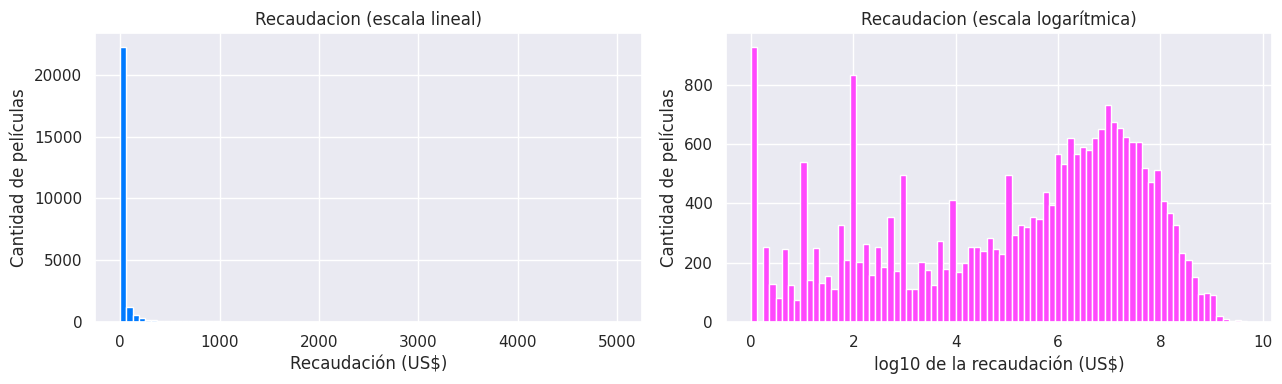

count    2.516600e+04
mean     3.572264e+07
std      1.456809e+08
min      1.000000e+00
5%       3.000000e+00
25%      1.000000e+03
50%      6.403460e+05
75%      1.260000e+07
95%      1.735431e+08
99%      6.700000e+08
max      5.000000e+09
Name: revenue, dtype: float64
Maxima recaudacion 4999999999


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

revenue_distribution = df.loc[df["revenue"] > 0, "revenue"]

axes[0].hist(revenue_distribution / 1e6, bins=80, color=AZUL, edgecolor="white")
axes[0].set_xlabel("Recaudación (US$)")
axes[0].set_ylabel("Cantidad de películas")
axes[0].set_title("Recaudacion (escala lineal)")

axes[1].hist(np.log10(revenue_distribution), bins=80, color=MAGENTA, edgecolor="white")
axes[1].set_xlabel("log10 de la recaudación (US$)")
axes[1].set_ylabel("Cantidad de películas")
axes[1].set_title("Recaudacion (escala logarítmica)")

plt.tight_layout()
plt.show()

print(revenue_distribution.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(0))
print(f"Maxima recaudacion {revenue_distribution.max()}")

Vemos que la recaudación tiene una distribucion con valores muy variados. En particular nos resalta la naturaleza de aquellas pocas peliculas que son exito financiero (**blockbusters**) y la inmensa mayoria de las peliculas recaudan poco o nada.

Dado que la escala lineal del histograma no nos dio mucha informacion utilizamos la escala logaritmica ($\log_{10}$) y observamos una distribucion que se asemeja a una normal.

Esto tiene dos consecuencias directas sobre el modelado:

1. **Vamos a entrenar sobre $\log(1 + \text{revenue})$**, no sobre `revenue`. Si no lo hacemos, el error cuadrático queda dominado por un puñado de *blockbusters* y el modelo ignora al resto del catálogo.
2. **Las métricas en dólares hay que leerlas con cuidado.** Un MAE de 40 millones puede ser excelente para *Avatar* y catastrófico para un documental. Por eso reportamos también el **MAE en $\log_{10}$**, que se interpreta como "en promedio le erramos por un factor de $10^{\text{MAE}}$".

---
## 4. Filtrado: del crudo al dataset de modelado

Antes de aplicar los filtros evaluamos cuantos datos vamos filtrando acumulativamente


Nos quedamos con las filas que cumplan:

- **`status == 'Released'`**: Peliculas lanzadas.
- **`revenue > 0` y `budget > 0`**: Datos financieros validos
- **`runtime > 0`**: descarta titulos sin duración cargada.
- **`vote_count > 0` & `vote_average > 0`**: `vote_count` & `vote_average` deben ser valores mayores que 0
- **Fecha de estreno y género no nulos**: sacamos los valores nulos

In [ ]:
filtros = [
    ("Dataset completo",              pd.Series(True, index=df.index)),
    ("status == 'Released'",          df["status"].eq("Released")),
    ("revenue > 0",                   df["revenue"] > 0),
    ("budget  > 0",                   df["budget"] > 0),
    ("runtime > 0",                   df["runtime"] > 0),
    ("vote_count > 0",                df["vote_count"] > 0),
    ("vote_average > 0",              df["vote_average"] > 0),
    ("fecha not null",        df["release_date"].notna()),
    ("género not null",          df["genres"].notna()),
]

mascara = pd.Series(True, index=df.index)
traza = []
for nombre, condicion in filtros:
    mascara &= condicion.fillna(False)
    traza.append({"filtro": nombre,
                  "filas": int(mascara.sum()),
                  "% del original": mascara.mean() * 100})

embudo = pd.DataFrame(traza).set_index("filtro").round(2)
embudo

,filas,% del original
filtro,,
Dataset completo,1480412,100.00
status == 'Released',1424043,96.19
revenue > 0,24781,1.67
budget > 0,17787,1.20
runtime > 0,14880,1.01
vote_count > 0,10773,0.73
vote_average > 0,10765,0.73
fecha not null,10593,0.72
género not null,10515,0.71


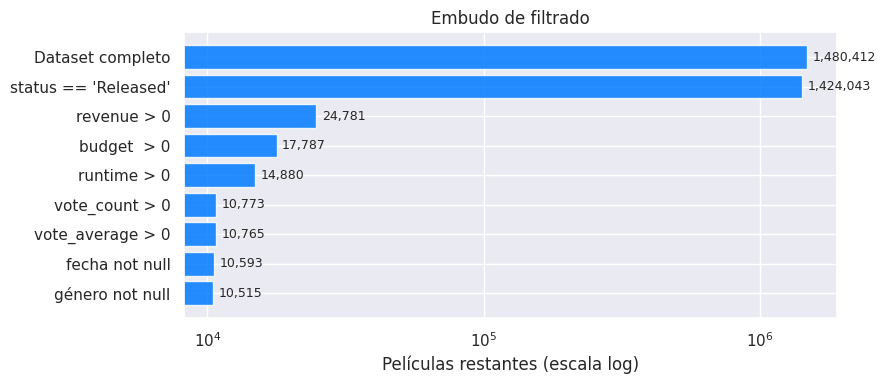

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
filas = embudo["filas"][::-1]
bars = ax.barh(embudo.index[::-1], filas, color=AZUL, alpha=0.85)
ax.bar_label(bars, labels=[f"{v:,}" for v in filas], padding=4, fontsize=9)
ax.set_xscale("log")
ax.set_xlabel("Películas restantes (escala log)")
ax.set_title("Embudo de filtrado")
plt.tight_layout()
plt.show()

Aplicamos los filtros de forma acumulativa para ver cuánto cuesta cada uno. El criterio general es quedarnos con **títulos estrenados que tengan cargados sus datos financieros**.


In [ ]:
peliculas = df[mascara].drop_duplicates(subset="id").reset_index(drop=True)

print(f"Dataset de modelado: {len(peliculas):,} películas "
      f"({len(peliculas) / len(df):.2%} del original)")
print(f"Años cubiertos: {peliculas['release_date'].dt.year.min():.0f}"
      f" – {peliculas['release_date'].dt.year.max():.0f}")

Dataset de modelado: 10,515 películas (0.71% del original)
Años cubiertos: 1913 – 2026


Nos quedamos con un dataset chico pero **denso en información**.

Sin embargo, en el proceso hemos introducido un sesgo de selección ya que las películas que tienen datos financieros cargados en TMDB son las comercialmente relevantes.

El modelo que entrenemos vale para ese universo y no para el catálogo completo. Lo retomamos en las conclusiones.

---
## 5. EDA sobre el dataset filtrado

### 5.1 Presupuesto contra recaudación

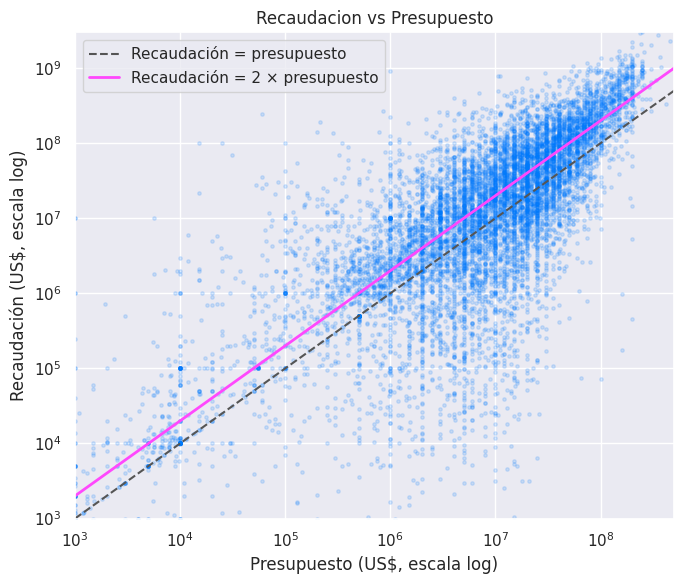

Media de revenue / budget: 1833.22
Mediana de revenue / budget: 1.75
Películas que no recuperan el presupuesto: 32.5%


In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(peliculas["budget"], peliculas["revenue"], s=6, alpha=0.15, color=AZUL)
ax.set_xscale("log")
ax.set_yscale("log")

lim = [1e3, 3e9]
ax.plot(lim, lim, color=GRIS, ls="--", lw=1.5, label="Recaudación = presupuesto")
ax.plot(lim, [2 * x for x in lim], color=MAGENTA, lw=2,
        label="Recaudación = 2 × presupuesto")

ax.set_xlim(1e3, 5e8)
ax.set_ylim(1e3, 3e9)
ax.set_xlabel("Presupuesto (US$, escala log)")
ax.set_ylabel("Recaudación (US$, escala log)")
ax.set_title("Recaudacion vs Presupuesto")
ax.legend()
plt.tight_layout()
plt.show()

ratio = peliculas["revenue"] / peliculas["budget"]
print(f"Media de revenue / budget: {ratio.mean():.2f}")
print(f"Mediana de revenue / budget: {ratio.median():.2f}")
print(f"Películas que no recuperan el presupuesto: {(ratio < 1).mean():.1%}")

En escala log-log la nube tiene una tendencia lineal clara: **el presupuesto es por lejos el mejor
predictor individual**. Pero la dispersión vertical alrededor de la tendencia es de más de un orden
de magnitud, y eso es exactamente lo que un modelo puede intentar explicar con el resto de las
variables.

La línea magenta es nuestra futura baseline: la regla del múltiplo del presupuesto `revenue =  k * budget`

Con respecto a los dos estadisticos utilizados, tenemos una media de 1.619 contra una mediana de 1.75. Esto quiere decir que en nuestros datos, la pelicula promedio recauda 1.619 veces su presupuesto, lo cual sabemos que no es el cierto.  Siendo que la media no es un estadistico robusto (sensible a los outliers) utilizaremos la mediana como un mejor estadistico en este caso.

Por ultimo resaltamos que el 32.5% de las peliculas no recuperan el presupuesto. Esto es consistente con el negocio

### 5.2 Correlaciones

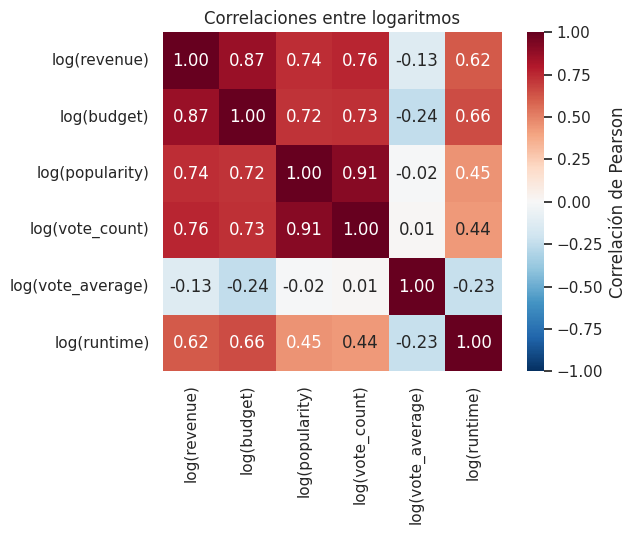

In [ ]:
numericas_eda = ["revenue", "budget", "popularity", "vote_count",
                 "vote_average", "runtime"]
log_eda = np.log1p(peliculas[numericas_eda])
log_eda.columns = [f"log({c})" for c in numericas_eda]

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(log_eda.corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, ax=ax,
            cbar_kws={"label": "Correlación de Pearson"})
ax.set_title("Correlaciones entre logaritmos")
plt.tight_layout()
plt.show()

Trabajamos con los logaritmos porque la correlación de Pearson sobre las variables originales estaría dominada por los valores extremos.

Llama bastante la atencion:

- `log(budget)` y `log(vote_count)` son las dos variables más correlacionadas con el target.
- `vote_average` casi no correlaciona. Es decir, que una película sea buena no implica que recaude, un resultado poco intuitivo pero muy consistente con lo que se sabe de la industria.

> `popularity`, `vote_count` y `vote_average` son variables medidas *después* del estreno. Nuestro modelo no las puede usar para decidir si financiar una película. Volvemos sobre esto al final.

### 5.3 Géneros y evolución temporal

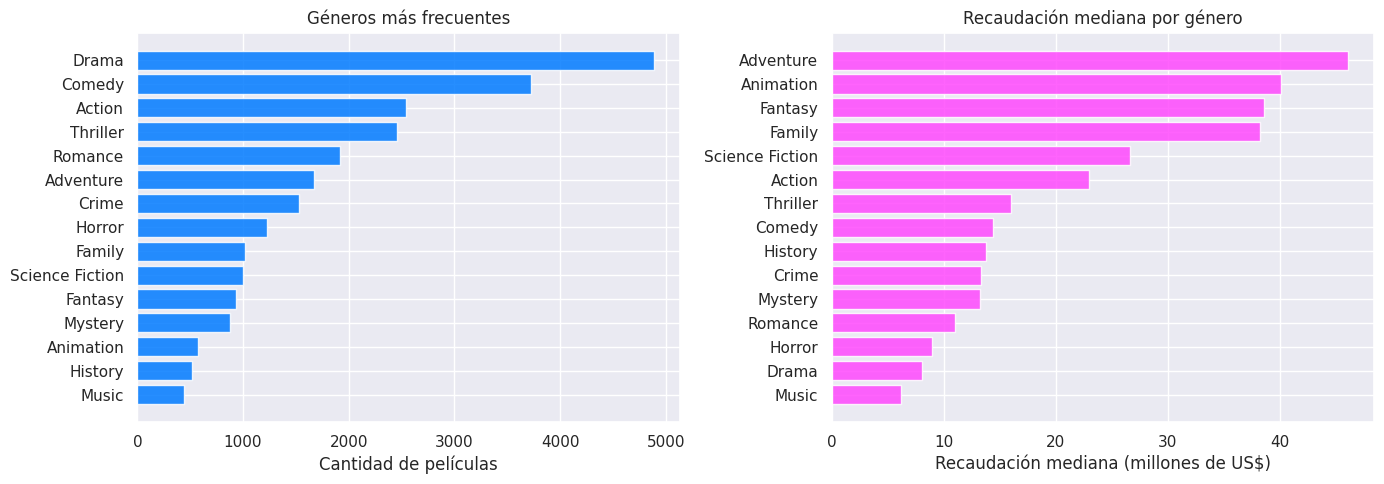

In [ ]:
def parsear_lista(valor):
    """Convierte 'Drama, Crimen' en ['Drama', 'Crimen']."""
    if pd.isna(valor):
        return []
    return [x.strip() for x in str(valor).split(",") if x.strip()]


generos_expandidos = peliculas["genres"].apply(parsear_lista).explode().dropna()
conteo_generos = generos_expandidos.value_counts()

recaudacion_por_genero = (
    peliculas.assign(genero=peliculas["genres"].apply(parsear_lista))
    .explode("genero")
    .groupby("genero")["revenue"]
    .median()
    .reindex(conteo_generos.index)
    / 1e6
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(conteo_generos.index[:15][::-1], conteo_generos.values[:15][::-1],
             color=AZUL, alpha=0.85)
axes[0].set_xlabel("Cantidad de películas")
axes[0].set_title("Géneros más frecuentes")

top15 = recaudacion_por_genero.head(15).sort_values()
axes[1].barh(top15.index, top15.values, color=MAGENTA, alpha=0.85)
axes[1].set_xlabel("Recaudación mediana (millones de US$)")
axes[1].set_title("Recaudación mediana por género")

plt.tight_layout()
plt.show()

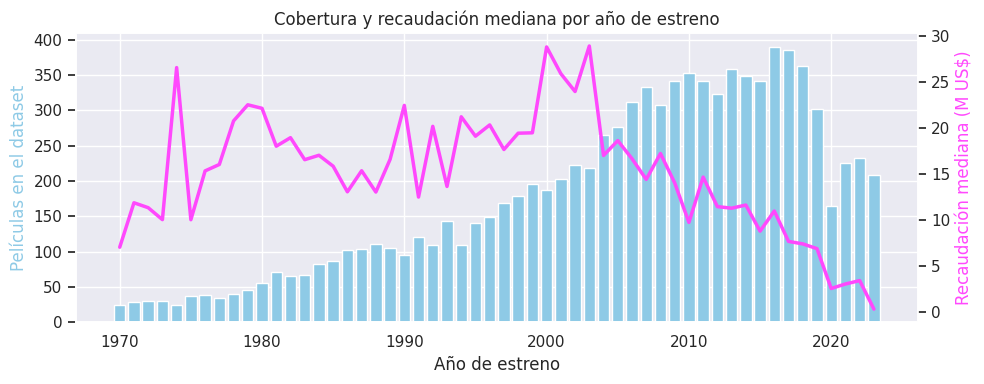

In [ ]:
por_anio = (peliculas
            .assign(anio=peliculas["release_date"].dt.year)
            .query("1970 <= anio <= 2023")
            .groupby("anio")
            .agg(peliculas=("revenue", "size"),
                 mediana=("revenue", "median")))

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(por_anio.index, por_anio["peliculas"], color=CELESTE, label="Películas")
ax.set_xlabel("Año de estreno")
ax.set_ylabel("Películas en el dataset", color=CELESTE)

ax2 = ax.twinx()
ax2.plot(por_anio.index, por_anio["mediana"] / 1e6, color=MAGENTA, lw=2.5,
         label="Recaudación mediana")
ax2.set_ylabel("Recaudación mediana (M US$)", color=MAGENTA)
ax2.grid(False)

ax.set_title("Cobertura y recaudación mediana por año de estreno")
plt.tight_layout()
plt.show()

La cobertura del dataset crece fuerte hacia el presente y la recaudación mediana **cae**: a medida
que se agregan estrenos recientes entran muchas producciones chicas que antes no se registraban. El
año de estreno, entonces, no es solo una variable temporal: también captura *cómo se armó el
dataset*. Lo incluimos como *feature* teniéndolo presente.

---
## 6. Ingeniería de *features*

Construimos la matriz de diseño con las variables elegidas y el tratamiento que necesita cada grupo:

| Grupo | Variables | Tratamiento |
|---|---|---|
| **Sesgadas** | `budget`, `popularity`, `vote_count`, `n_companias` | $\log(1+x)$ y luego estandarización |
| **Numéricas** | `runtime`, `vote_average`, `anio` | Estandarización |
| **Categórica** | `idioma` (8 más frecuentes + `otro`) | *One-hot* |
| **Binarias** | 12 indicadores de género | Se pasan tal cual (ya son 0/1) |



- Las variables `budget`, `popularity` y `vote_count` abarcan varios órdenes de magnitud, igual que el target. Estandarizarlas directamente dejaría casi todas las películas amontonadas cerca de cero y unas pocas a diez desvíos de distancia. Aplicamos $\log(1+x)$ para convertirlas aproximadamente simétricas para luego estandarizarlas.

- La variables de `idioma` es multietiqueta. Asumiendo que cada pelicula tiene un unico idioma principal, aplicamos `OneHotEncoder`

- Estandarizamos las demas variables para que los modelos tengan una comparación limpia.

In [ ]:
TOP_GENEROS = conteo_generos.head(12).index.tolist()
TOP_IDIOMAS = peliculas["original_language"].value_counts().head(8).index.tolist()

print(f"Géneros: {TOP_GENEROS}")
print(f"Idiomas: {TOP_IDIOMAS}")

Géneros: ['Drama', 'Comedy', 'Action', 'Thriller', 'Romance', 'Adventure', 'Crime', 'Horror', 'Family', 'Science Fiction', 'Fantasy', 'Mystery']
Idiomas: ['en', 'hi', 'fr', 'ru', 'es', 'ja', 'ta', 'zh']


In [ ]:
def construir_features(datos):
    """Arma la matriz de diseño a partir del dataframe filtrado."""
    listas_generos = datos["genres"].apply(parsear_lista)

    matriz = pd.DataFrame(index=datos.index)

    # Sesgadas (se les aplica log en el pipeline)
    matriz["budget"] = datos["budget"]
    matriz["popularity"] = datos["popularity"]
    matriz["vote_count"] = datos["vote_count"]
    matriz["n_companias"] = (datos["production_companies"]
                             .apply(parsear_lista).str.len())

    # Numéricas
    matriz["runtime"] = datos["runtime"]
    matriz["vote_average"] = datos["vote_average"]
    matriz["anio"] = datos["release_date"].dt.year

    # Categórica: los idiomas poco frecuentes se agrupan en "otro"
    matriz["idioma"] = datos["original_language"].where(
        datos["original_language"].isin(TOP_IDIOMAS), "otro")

    # Binarias: un indicador por género (multietiqueta)
    for genero in TOP_GENEROS:
        columna = "gen_" + genero.lower().replace(" ", "_")
        matriz[columna] = listas_generos.apply(lambda gs, g=genero: int(g in gs))

    return matriz


SESGADAS = ["budget", "popularity", "vote_count", "n_companias"]
NUMERICAS = ["runtime", "vote_average", "anio"]
CATEGORICAS = ["idioma"]
BINARIAS = ["gen_" + g.lower().replace(" ", "_") for g in TOP_GENEROS]

X = construir_features(peliculas)
y = peliculas["revenue"]

print(f"Matriz de features: {X.shape[0]:,} filas × {X.shape[1]} columnas")
X.head()

Matriz de features: 10,515 filas × 20 columnas


,budget,popularity,vote_count,n_companias,runtime,vote_average,anio,idioma,gen_drama,gen_comedy,gen_action,gen_thriller,gen_romance,gen_adventure,gen_crime,gen_horror,gen_family,gen_science_fiction,gen_fantasy,gen_mystery
0,160000000,83.952,34495,3,148,8.364,2010,en,0,0,1,0,0,1,0,0,0,1,0,0
1,165000000,140.241,32571,3,169,8.417,2014,en,1,0,0,0,0,1,0,0,0,1,0,0
2,185000000,130.643,30619,5,152,8.512,2008,en,1,0,1,1,0,0,1,0,0,0,0,0
3,237000000,79.932,29815,4,162,7.573,2009,en,0,0,1,0,0,1,0,0,0,1,1,0
4,220000000,98.082,29166,1,143,7.710,2012,en,0,0,1,0,0,1,0,0,0,1,0,0


### Nulos

Verificamos que no queden valores faltantes antes de entrenar. Los filtros de la sección 4 ya
descartaron implícitamente casi todos, pero validamos por las dudas. Descartamos las filas incompletas en lugar de imputarlas.

In [ ]:
nulos_por_columna = X.isna().sum()
print("Nulos por columna:")
print(nulos_por_columna[nulos_por_columna > 0]
      if nulos_por_columna.any() else "  (ninguno)")

completas = X.notna().all(axis=1) & y.notna()

X, y = X[completas], y[completas]
print(f"\nFilas descartadas por nulos: {(~completas).sum()}")
print(f"Dataset final: {len(X):,} películas × {X.shape[1]} features")

Nulos por columna:
  (ninguno)

Filas descartadas por nulos: 0
Dataset final: 10,515 películas × 20 features


Hacemos el split para obtener nuestro conjunto de entrenamiento y nuestro conjunto de evaluacion

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)

print(f"Entrenamiento: {len(X_train):,} películas")
print(f"Testeo:        {len(X_test):,} películas")

Entrenamiento: 8,412 películas
Testeo:        2,103 películas


---
## 7. Función de evaluación

Reproducimos la función `evaluar` que venimos usando en la materia, con tres adaptaciones para este
problema:

- Los montos se reportan en **millones de dólares** para que la tabla sea legible.
- Agregamos el **MAE en $\log_{10}$**, que mide el error en órdenes de magnitud y no queda secuestrado por los *blockbusters*.
- **Reemplazamos el MAPE por su versión mediana MedAPE** porque la mediana es robusta ante outliers.

In [ ]:
def mae_log10(y_true, y_pred):
    """Error absoluto medio en órdenes de magnitud."""
    return mean_absolute_error(np.log10(np.clip(y_true, 1, None)),
                               np.log10(np.clip(y_pred, 1, None)))


# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.median_absolute_error.html
def medape(y_true, y_pred):
    """Error porcentual MEDIANO: versión robusta del MAPE."""
    return float(np.median(np.abs(y_true - y_pred) / y_true))


def evaluar(nombre, modelo, cv=True):
    """Entrena, evalúa en test y opcionalmente estima el MAE por CV."""
    millon = 1e6
    mae_cv = np.nan
    if cv:
        mae_cv = -cross_val_score(modelo, X_train, y_train, cv=5,
                                  scoring="neg_mean_absolute_error",
                                  n_jobs=-1).mean()

    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    return {
        "modelo": nombre,
        "MAE train [M US$]": mean_absolute_error(
            y_train, modelo.predict(X_train)) / millon,
        "MAE CV [M US$]": mae_cv / millon,
        "MAE test [M US$]": mean_absolute_error(y_test, y_pred) / millon,
        "RMSE [M US$]": root_mean_squared_error(y_test, y_pred) / millon,
        "MedAPE": medape(y_test, y_pred),
        "MAE log10": mae_log10(y_test, y_pred),
        "R2": r2_score(y_test, y_pred),
    }

---
## 8. Baselines

Como mencionamos en el planteo del problema, utilizamos como baseline la regla de oro informal "una película recauda dos o tres veces su presupuesto":

$$\widehat{\text{revenue}} = k \cdot \text{budget}$$

utilizando $k$ estimado como la **mediana** del cociente $\text{revenue}/\text{budget}$ en el conjunto de entrenamiento, ya que representa un estadistico robusto.


$$\widehat{\text{revenue}} = (1.75) \cdot \text{budget}$$

Implementamos el baseline como un estimador de scikit-learn (siguiendo la misma API) para que pase por la misma función `evaluar` que los demas modelos.

In [ ]:
class BaseLine(RegressorMixin, BaseEstimator):
    """Regla de la industria: revenue = k · budget, con k = mediana del ratio."""

    def __init__(self, columna="budget"):
        self.columna = columna

    def fit(self, X, y):  # noqa: N803
        self.k_ = float(np.median(np.asarray(y) / X[self.columna].to_numpy()))
        return self

    def predict(self, X):  # noqa: N803
        return self.k_ * X[self.columna].to_numpy()

In [ ]:
# Guardamos los estimadores en un diccionario, la funcion "evaluar" ya lo deja entrenado
estimadores = {
    "Modelo baseline" : BaseLine()
}

baselines = [evaluar(nombre, estimador) for nombre, estimador in estimadores.items()]
pd.DataFrame(baselines).set_index("modelo").round(3)

,MAE train [M US$],MAE CV [M US$],MAE test [M US$],RMSE [M US$],MedAPE,MAE log10,R2
modelo,,,,,,,
Modelo baseline,42.324,42.353,43.34,125.504,0.721,0.594,0.372


In [ ]:
k = estimadores["Modelo baseline"].k_
ratios = y_train / X_train["budget"]

print(f"Múltiplo aprendido en entrenamiento: k = {k:.2f}")
print(f"Cuartiles del ratio revenue/budget:  "
      f"{ratios.quantile(0.25):.2f}  |  {ratios.quantile(0.5):.2f}  |  "
      f"{ratios.quantile(0.75):.2f}")

Múltiplo aprendido en entrenamiento: k = 1.75
Cuartiles del ratio revenue/budget:  0.65  |  1.75  |  3.88


La regla captura una porción considerable de la señal con un único parámetro, y su $R^2$ positivo
confirma que es una heuristica base buena como punto de partida.

Dos observaciones sobre el $k$ obtenido:

- **Queda por debajo del tipico "dos o tres veces".** No es que la regla de la industria esté
  mal, es que se refiere a los estrenos grandes: nuestro dataset incluye producciones chicas y un
  tercio de las películas no recupera su presupuesto, por eso la mediana del ratio lo refleja
- **Utilizamos la mediana sobre el promedio** por ser un estadistico robusto. El cociente
  $\text{revenue}/\text{budget}$ tiene una cola derecha extremísima y el promedio quedaría dominado por ellas

---
## 9. Modelos

A partir de los modelos estudiados a lo largo de la materia los cuales incluimos a todos en su mayoria (salvo ensambles, que se elijio uno representativo de bagging y otro de boosting), le añadimos un modelo `baseline` heuristico basado en informacion del negocio y `ridge` que no es otra cosa que un modelo de regresion lineal con regularizacion, teniendo en cuenta que visualmente de antemano vemos que existe una tendencia lineal a priori.

| Modelo | Familia | Clase | Qué pregunta responde |
|---|---|---|---|
| **Múltiplo del presupuesto** | Heurística de dominio | Heuristica | *Referencia.* ¿Cuánto se logra con una sola variable y un solo parámetro? |
| **Ridge** | Lineal regularizada | Materia anterior | *Referencia.* ¿La relación es esencialmente lineal en logaritmos? Mide cuánto aporta la no linealidad. |
| **KNN** | Distancias locales | 2 | ¿Alcanza con promediar "películas parecidas"? Es el más expuesto a la maldición de la dimensionalidad. |
| **SVR (RBF)** | Márgenes y kernels | 3 | ¿El fenómeno es una superficie continua y suave? Único modelo que optimiza una pérdida ε-insensible. |
| **Árbol de regresión** | Particionamiento recursivo | 4 | ¿Qué aprende realmente el modelo? Es el único que se puede leer, y la unidad base de los ensambles. |
| **Random Forest** | *Bagging* de árboles | 5 | ¿Cuánto se gana promediando árboles decorrelacionados? Ataca la varianza. |
| **XGBoost** | *Boosting* de árboles | 5 | ¿Cuánto se gana corrigiendo residuos en serie? Ataca el sesgo. |


La secuencia **Arbol de regresion → Random Forest (ensamble promediado) → XGBoost (ensamble secuencial)** permite medir por separado el aporte del particionamiento, el del promediado y el de la corrección secuencial, en lugar de presentar el ensamble como una caja negra que funciona mejor porque sí.

La pregunta que tratamos de responder no es `cuál elegir` sino `cuál gana y por qué`.

### Preprocesamiento

Todos comparten el mismo `ColumnTransformer`. Las variables sesgadas pasan por $\log(1+x)$ antes de
estandarizarse; a los árboles no les hace falta, pero mantener un único preprocesador hace la
comparación limpia y no los perjudica (una transformación monótona no cambia los cortes).

El target se transforma con `TransformedTargetRegressor`: **todos** los modelos aprenden sobre
$\log(1+\text{revenue})$ y devuelven predicciones en dólares.

In [ ]:
preprocesador = ColumnTransformer([
    # log + estandarización para las variables de muchos órdenes de magnitud
    ("sesgadas", Pipeline([("log", FunctionTransformer(np.log1p)),
                           ("escala", StandardScaler())]), SESGADAS),
    # estandarización a secas para el resto de las numéricas
    ("numericas", StandardScaler(), NUMERICAS),
    # one-hot para la categórica
    ("categoricas", OneHotEncoder(handle_unknown="ignore",
                                  sparse_output=False), CATEGORICAS),
    # los indicadores de género ya son 0/1
    ("binarias", "passthrough", BINARIAS),
])


def armar(estimador):
    """Preprocesamiento + modelo, con el target en escala logarítmica."""
    return TransformedTargetRegressor(
        regressor=Pipeline([("prep", preprocesador),
                            ("modelo", clone(estimador))]),
        func=np.log1p,
        inverse_func=np.expm1,
    )

In [ ]:
modelos = {
    "Ridge": Ridge(alpha=1.0),
    "SVR (RBF)":    SVR(kernel="rbf", C=10.0, epsilon=0.1, gamma="scale"),
    "KNN (k=15)": KNeighborsRegressor(n_neighbors=15, weights="distance"),
    "Árbol de regresion": DecisionTreeRegressor(criterion='squared_error', max_depth=8, min_samples_leaf=10, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(
        n_estimators=400, min_samples_leaf=2,
        random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": XGBRegressor(
        n_estimators=600, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, n_jobs=-1),
}

In [ ]:


estimadores.update({nombre: armar(est) for nombre, est in modelos.items()})

resultados = [evaluar(nombre, estimadores[nombre]) for nombre in modelos]

pd.DataFrame(resultados).set_index("modelo").round(3)

,MAE train [M US$],MAE CV [M US$],MAE test [M US$],RMSE [M US$],MedAPE,MAE log10,R2
modelo,,,,,,,
Ridge,32.698,32.978,33.481,96.918,0.632,0.516,0.626
SVR (RBF),20.540,29.665,29.221,86.120,0.566,0.453,0.704
KNN (k=15),0.000,35.592,35.529,105.550,0.647,0.523,0.556
Árbol de regresion,29.437,33.068,34.141,96.204,0.670,0.534,0.631
Random Forest,14.558,28.964,30.395,89.232,0.589,0.474,0.683
XGBoost,22.558,28.333,28.809,86.371,0.574,0.469,0.703


### 9.1 Comparativa completa

Antes de buscar hiper-parametros optimos, hacemos una comparativa inicial entre las predicciones de cada modelo para tener una idea de como se ajusta cada modelo a los datos

In [ ]:
comparativa = pd.DataFrame(baselines + resultados).set_index("modelo")
comparativa.round(3)

,MAE train [M US$],MAE CV [M US$],MAE test [M US$],RMSE [M US$],MedAPE,MAE log10,R2
modelo,,,,,,,
Modelo baseline,42.324,42.353,43.340,125.504,0.721,0.594,0.372
Ridge,32.698,32.978,33.481,96.918,0.632,0.516,0.626
SVR (RBF),20.540,29.665,29.221,86.120,0.566,0.453,0.704
KNN (k=15),0.000,35.592,35.529,105.550,0.647,0.523,0.556
Árbol de regresion,29.437,33.068,34.141,96.204,0.670,0.534,0.631
Random Forest,14.558,28.964,30.395,89.232,0.589,0.474,0.683
XGBoost,22.558,28.333,28.809,86.371,0.574,0.469,0.703


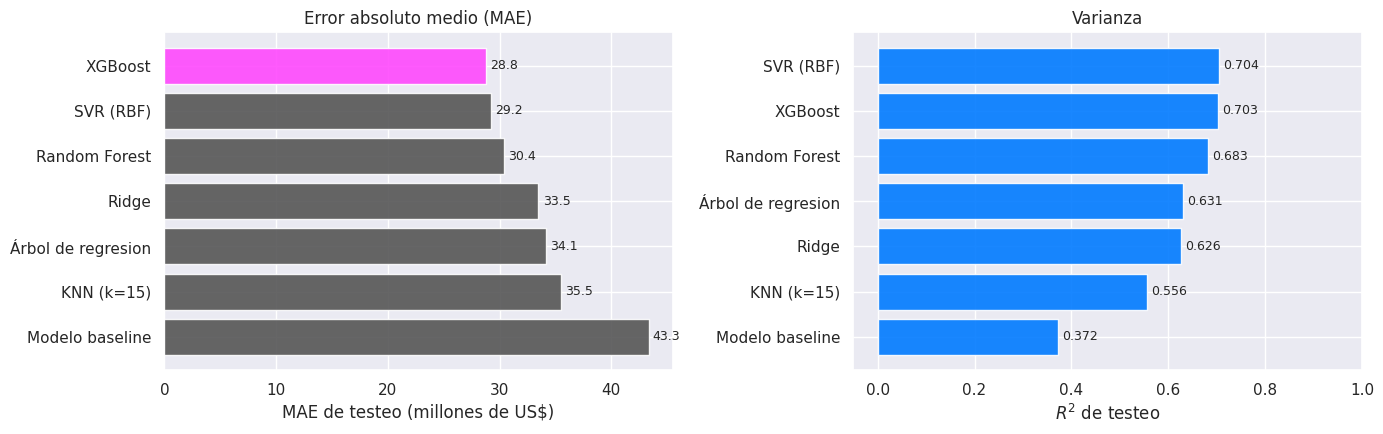

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

orden = comparativa.sort_values("MAE test [M US$]")
colores = [GRIS] * len(orden)
colores[0] = MAGENTA  # el mejor

bars = axes[0].barh(orden.index[::-1], orden["MAE test [M US$]"][::-1],
                    color=colores[::-1], alpha=0.9)
axes[0].bar_label(bars, fmt="%.1f", padding=3, fontsize=9)
axes[0].set_xlabel("MAE de testeo (millones de US$)")
axes[0].set_title("Error absoluto medio (MAE)")

orden_r2 = comparativa.sort_values("R2", ascending=False)
bars = axes[1].barh(orden_r2.index[::-1], orden_r2["R2"][::-1],
                    color=AZUL, alpha=0.9)
axes[1].bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
axes[1].set_xlabel("$R^2$ de testeo")
axes[1].set_title("Varianza")
axes[1].set_xlim(min(0, orden_r2["R2"].min()) - 0.05, 1)

plt.tight_layout()
plt.show()

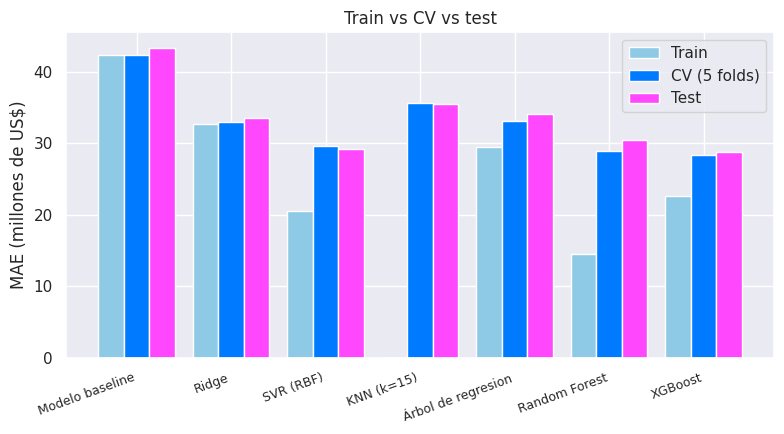

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))

sub = comparativa.dropna(subset=["MAE CV [M US$]"])
posiciones = np.arange(len(sub))
ancho = 0.27

ax.bar(posiciones - ancho, sub["MAE train [M US$]"], ancho,
       label="Train", color=CELESTE)
ax.bar(posiciones, sub["MAE CV [M US$]"], ancho, label="CV (5 folds)", color=AZUL)
ax.bar(posiciones + ancho, sub["MAE test [M US$]"], ancho, label="Test", color=MAGENTA)

ax.set_xticks(posiciones)
ax.set_xticklabels(sub.index, rotation=20, ha="right", fontsize=9)
ax.set_ylabel("MAE (millones de US$)")
ax.set_title("Train vs CV vs test")
ax.legend()
plt.tight_layout()
plt.show()

La comparación **train / CV / test** es la que más información da sobre el comportamiento de cada
modelo, porque el valor informativo está en las **diferencias** y no en cada número por separado:

- **Train contra CV** mide la varianza del modelo. El baseline tiene las tres barras casi iguales
  (con un solo parámetro no hay capacidad para sobreajustar), mientras que Random Forest baja a
  14,6 M US$ en entrenamiento contra 29,0 en validación cruzada. Esa brecha es sobreajuste.
- **CV contra test** valida que la comparación no esté contaminada. Si los dos números son
  consistentes, ni hubo fuga de información ni la búsqueda de hiperparámetros se sobreajustó a los
  pliegues. El árbol de regresión es el que más se despega (32,6 contra 35,2), señal de su alta
  varianza: su desempeño depende demasiado de qué películas le toquen.

El caso extremo es **KNN, con un MAE de entrenamiento exactamente cero**. No es un error de cálculo:
al usar `weights="distance"`, el vecino que está a distancia cero (la propia película, que está en
el conjunto de entrenamiento) recibe peso infinito y la predicción la reproduce exacta. KNN
*memoriza* el entrenamiento por construcción, así que en este modelo el MAE de entrenamiento no
informa absolutamente nada y hay que mirar sí o sí el de validación cruzada. Es la mejor ilustración
de por qué las tres columnas se leen juntas: ordenar la tabla por MAE de entrenamiento coronaría al
peor modelo del trabajo.

### 9.2 Ajuste de hiperparámetros

Hasta acá todos los modelos corrieron con configuraciones razonables pero elegidas a mano. Ahora
los ajustamos **a todos**, no solo al que iba ganando: comparar un modelo optimizado contra cinco
sin optimizar no diría nada sobre cuál es mejor, solo sobre cuál recibió más atención.

| Modelo | Hiperparámetros | Método | Referencia |
|---|---|---|---|
| Ridge | `alpha` | `GridSearchCV` en escala logarítmica | Materia anterior — Regresión Lineal |
| KNN | `n_neighbors`, `weights`, `p` | `GridSearchCV` | clase 2 — Hiper-parámetros |
| SVR (RBF) | `C`, `gamma`, `epsilon` | `GridSearchCV` | clase 3 — SVM como regresión |
| Árbol de regresión | `max_depth`, `min_samples_leaf` | `GridSearchCV` | clase 4 — Árboles de regresión |
| Random Forest | `max_features` | Barrido por CV | clase 5 — Comparativa final |
| XGBoost | 8 hiperparámetros | **Optuna** (TPE) | clase 5 — Boosting y XGBoost |

Las seis búsquedas usan **validación cruzada de 5 pliegues sobre el conjunto de entrenamiento** y
optimizan MAE. El conjunto de testeo no participa de ninguna: se toca una sola vez, al final.

El método no es el mismo para todos, y la diferencia es de escala del espacio de búsqueda. Con uno
o dos hiperparámetros, una grilla exhaustiva recorre todas las combinaciones y garantiza encontrar
el óptimo dentro del rango explorado. Con los ocho de XGBoost eso sería inviable —una grilla de solo
cuatro valores por hiperparámetro son 65.536 combinaciones—, así que usamos Optuna, que concentra
los intentos en las zonas prometedoras del espacio en lugar de recorrerlo todo por igual.

In [ ]:
ajustados = {}   # nombre -> estimador ya optimizado


def buscar_en_grilla(nombre, grilla):
    """GridSearchCV sobre el pipeline completo, optimizando MAE por CV."""
    busqueda = GridSearchCV(armar(modelos[nombre]), param_grid=grilla,
                            scoring="neg_mean_absolute_error", cv=5, n_jobs=-1)
    busqueda.fit(X_train, y_train)

    limpio = {k.split("__")[-1]: v for k, v in busqueda.best_params_.items()}
    print(f"{nombre:<16} MAE CV = {-busqueda.best_score_ / 1e6:5.2f} M US$   {limpio}")
    ajustados[nombre] = busqueda.best_estimator_
    return busqueda

#### Ridge

Para Ridge la grilla recorre `alpha` en escala logarítmica ya que es el único hiperparámetro que tiene. El mismo controla cuánto se penalizan los coeficientes grandes.

In [ ]:
buscar_en_grilla("Ridge", {
    "regressor__modelo__alpha": [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
})

Ridge            MAE CV = 32.97 M US$   {'alpha': 0.01}


GridSearchCV(cv=5,
             estimator=TransformedTargetRegressor(func=<ufunc 'log1p'>,
                                                  inverse_func=<ufunc 'expm1'>,
                                                  regressor=Pipeline(steps=[('prep',
                                                                             ColumnTransformer(transformers=[('sesgadas',
                                                                                                              Pipeline(steps=[('log',
                                                                                                                               FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                                                                              ('escala',
                                                                                                                               StandardScaler())]),
                                                                                                              ['budget',
                                                                                                               'popularity',
                                                                                                               'vote_count',
                                                                                                               'n_companias']),
                                                                                                             ('numericas',
                                                                                                              StandardS...
                                                                                                              ['idioma']),
                                                                                                             ('binarias',
                                                                                                              'passthrough',
                                                                                                              ['gen_drama',
                                                                                                               'gen_comedy',
                                                                                                               'gen_action',
                                                                                                               'gen_thriller',
                                                                                                               'gen_romance',
                                                                                                               'gen_adventure',
                                                                                                               'gen_crime',
                                                                                                               'gen_horror',
                                                                                                               'gen_family',
                                                                                                               'gen_science_fiction',
                                                                                                               'gen_fantasy',
                                                                                                               'gen_mystery'])])),
                                                                            ('modelo',
                                                                             Ridge())])),
             n_jobs=-1,
             param_grid={'regressor__modelo__alpha': [0.01, 0.1, 1.0, 10.0,
                                                      100.0, 1000.0]},
             scoring='neg_mean_absolute_error')

#### K Nearest neighbors (KNN)

En KNN la grilla ajusta tres hiperparámetros a la vez:

1. la cantidad de vecinos,
2. si se los pondera por distancia,
3. y la métrica (`p=1` es Manhattan, `p=2` es Euclídea).

In [ ]:
buscar_en_grilla("KNN (k=15)", {
    "regressor__modelo__n_neighbors": [5, 10, 15, 25, 40],
    "regressor__modelo__weights": ["uniform", "distance"],
    "regressor__modelo__p": [1, 2],
})

KNN (k=15)       MAE CV = 34.28 M US$   {'n_neighbors': 15, 'p': 1, 'weights': 'distance'}


GridSearchCV(cv=5,
             estimator=TransformedTargetRegressor(func=<ufunc 'log1p'>,
                                                  inverse_func=<ufunc 'expm1'>,
                                                  regressor=Pipeline(steps=[('prep',
                                                                             ColumnTransformer(transformers=[('sesgadas',
                                                                                                              Pipeline(steps=[('log',
                                                                                                                               FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                                                                              ('escala',
                                                                                                                               StandardScaler())]),
                                                                                                              ['budget',
                                                                                                               'popularity',
                                                                                                               'vote_count',
                                                                                                               'n_companias']),
                                                                                                             ('numericas',
                                                                                                              StandardS...
                                                                                                               'gen_adventure',
                                                                                                               'gen_crime',
                                                                                                               'gen_horror',
                                                                                                               'gen_family',
                                                                                                               'gen_science_fiction',
                                                                                                               'gen_fantasy',
                                                                                                               'gen_mystery'])])),
                                                                            ('modelo',
                                                                             KNeighborsRegressor(n_neighbors=15,
                                                                                                 weights='distance'))])),
             n_jobs=-1,
             param_grid={'regressor__modelo__n_neighbors': [5, 10, 15, 25, 40],
                         'regressor__modelo__p': [1, 2],
                         'regressor__modelo__weights': ['uniform', 'distance']},
             scoring='neg_mean_absolute_error')

#### SVR (RBF)

SVR tiene tres hiperparámetros que interactúan fuertemente entre sí:

- **`C`** — Indica cuánto se penaliza que una película quede fuera del tubo. Es el control de
  regularización, con la parametrización invertida respecto de Ridge: más `C` significa **menos**
  regularización. Se explora en escala logarítmica porque lo que importa es el orden de magnitud.
- **`gamma`** — Indica el ancho del kernel RBF, es decir, hasta qué distancia una película influye sobre
  otra. El default `"scale"` vale $1/(n_{\text{features}} \cdot \text{Var}(X))$.
- **`epsilon`** — Indica el ancho del tubo dentro del cual un error **no cuesta nada**. Es la particularidad
  de SVR; a diferencia de todos los demás modelos, no minimiza el error de todas las observaciones
  sino solo el de las que caen fuera del margen (los *vectores de soporte*). Va en unidades del
  target.

In [ ]:
buscar_en_grilla("SVR (RBF)", {
    "regressor__modelo__C": [1.0, 10.0, 100.0],
    "regressor__modelo__gamma": ["scale", 0.01, 0.2],
    "regressor__modelo__epsilon": [0.05, 0.2],
})

SVR (RBF)        MAE CV = 28.33 M US$   {'C': 100.0, 'epsilon': 0.2, 'gamma': 0.01}


GridSearchCV(cv=5,
             estimator=TransformedTargetRegressor(func=<ufunc 'log1p'>,
                                                  inverse_func=<ufunc 'expm1'>,
                                                  regressor=Pipeline(steps=[('prep',
                                                                             ColumnTransformer(transformers=[('sesgadas',
                                                                                                              Pipeline(steps=[('log',
                                                                                                                               FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                                                                              ('escala',
                                                                                                                               StandardScaler())]),
                                                                                                              ['budget',
                                                                                                               'popularity',
                                                                                                               'vote_count',
                                                                                                               'n_companias']),
                                                                                                             ('numericas',
                                                                                                              StandardS...
                                                                                                               'gen_action',
                                                                                                               'gen_thriller',
                                                                                                               'gen_romance',
                                                                                                               'gen_adventure',
                                                                                                               'gen_crime',
                                                                                                               'gen_horror',
                                                                                                               'gen_family',
                                                                                                               'gen_science_fiction',
                                                                                                               'gen_fantasy',
                                                                                                               'gen_mystery'])])),
                                                                            ('modelo',
                                                                             SVR(C=10.0))])),
             n_jobs=-1,
             param_grid={'regressor__modelo__C': [1.0, 10.0, 100.0],
                         'regressor__modelo__epsilon': [0.05, 0.2],
                         'regressor__modelo__gamma': ['scale', 0.01, 0.2]},
             scoring='neg_mean_absolute_error')

#### Árbol de regresión

Ajustamos los dos mecanismos de poda más directos. `max_depth` limita cuántas preguntas encadenadas
puede hacer el árbol; `min_samples_leaf` impide que las hojas se apoyen en tan pocas películas que
terminen ajustando ruido. Incluimos `max_depth = None` deliberadamente, para verificar que el árbol
sin podar es el peor y no el mejor: sin límite, memoriza el conjunto de entrenamiento.

In [ ]:
buscar_en_grilla("Árbol de regresion", {
    "regressor__modelo__max_depth": [4, 6, 8, 10, 12, None],
    "regressor__modelo__min_samples_leaf": [1, 5, 10, 20, 50],
})

Árbol de regresion MAE CV = 32.82 M US$   {'max_depth': 12, 'min_samples_leaf': 20}


GridSearchCV(cv=5,
             estimator=TransformedTargetRegressor(func=<ufunc 'log1p'>,
                                                  inverse_func=<ufunc 'expm1'>,
                                                  regressor=Pipeline(steps=[('prep',
                                                                             ColumnTransformer(transformers=[('sesgadas',
                                                                                                              Pipeline(steps=[('log',
                                                                                                                               FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                                                                              ('escala',
                                                                                                                               StandardScaler())]),
                                                                                                              ['budget',
                                                                                                               'popularity',
                                                                                                               'vote_count',
                                                                                                               'n_companias']),
                                                                                                             ('numericas',
                                                                                                              StandardS...
                                                                                                               'gen_adventure',
                                                                                                               'gen_crime',
                                                                                                               'gen_horror',
                                                                                                               'gen_family',
                                                                                                               'gen_science_fiction',
                                                                                                               'gen_fantasy',
                                                                                                               'gen_mystery'])])),
                                                                            ('modelo',
                                                                             DecisionTreeRegressor(max_depth=8,
                                                                                                   min_samples_leaf=10,
                                                                                                   random_state=42))])),
             n_jobs=-1,
             param_grid={'regressor__modelo__max_depth': [4, 6, 8, 10, 12,
                                                          None],
                         'regressor__modelo__min_samples_leaf': [1, 5, 10, 20,
                                                                 50]},
             scoring='neg_mean_absolute_error')

#### Random Forest

Evaluamos distintos valores para `max_features`, el cual representa cuántas variables considera cada árbol al elegir un corte.

Recordemos que en el caso de `max_features=1.0` cada árbol mira todas las columnas y el ensamble se reduce a *bagging* de árboles.

In [ ]:
opciones_mf = ["sqrt", 0.3, 0.5, 0.7, 1.0]
filas_mf = []

for mf in opciones_mf:
    candidato = RandomForestRegressor(n_estimators=400, max_features=mf,
                                      min_samples_leaf=2,
                                      random_state=RANDOM_STATE, n_jobs=-1)
    mae_cv = -cross_val_score(armar(candidato), X_train, y_train, cv=5,
                              scoring="neg_mean_absolute_error").mean()
    filas_mf.append({"max_features": str(mf), "MAE CV [M US$]": mae_cv / 1e6})

tabla_mf = pd.DataFrame(filas_mf).set_index("max_features")

mejor_mf = opciones_mf[int(np.argmin(tabla_mf["MAE CV [M US$]"]))]
ajustados["Random Forest"] = armar(RandomForestRegressor(
    n_estimators=400, max_features=mejor_mf, min_samples_leaf=2,
    random_state=RANDOM_STATE, n_jobs=-1))

print(f"Mejor max_features: {mejor_mf}")
tabla_mf.round(3)

Mejor max_features: 0.7


,MAE CV [M US$]
max_features,
sqrt,31.424
0.3,29.794
0.5,29.071
0.7,28.907
1.0,28.964


In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 4))
barras = ax.bar(tabla_mf.index, tabla_mf["MAE CV [M US$]"], color=AZUL, alpha=0.85)
ax.bar_label(barras, fmt="%.2f", padding=3, fontsize=9)
ax.set_ylim(tabla_mf["MAE CV [M US$]"].min() * 0.97,
            tabla_mf["MAE CV [M US$]"].max() * 1.02)
ax.set_ylabel("MAE por validación cruzada (M US$)")
ax.set_xlabel("max_features")
ax.set_title("Cuánta aleatoriedad de atributos conviene")
ax.annotate("= bagging", xy=(4, tabla_mf["MAE CV [M US$]"].iloc[-1]),
            xytext=(3.4, tabla_mf["MAE CV [M US$]"].max()),
            fontsize=9, color=GRIS,
            arrowprops={"arrowstyle": "->", "color": GRIS})
plt.tight_layout()
plt.show()

#### XGBoost

XGBoost tiene demasiados hiperparámetros para una grilla. Para eso utilizamos Optuna para que vaya concentrando los intentos en las zonas prometedoras del espacio.

In [ ]:
N_TRIALS = 150   # la clase 5 usa 300; bajarlo o subirlo solo cambia el tiempo

optuna.logging.set_verbosity(optuna.logging.ERROR)


def objetivo(trial):
    """MAE por validación cruzada de una configuración propuesta por Optuna."""
    candidato = XGBRegressor(
        n_estimators=trial.suggest_int("n_estimators", 100, 1000, step=50),
        learning_rate=trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
        max_depth=trial.suggest_int("max_depth", 2, 8),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.4, 1.0),
        min_child_weight=trial.suggest_int("min_child_weight", 1, 15),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 20, log=True),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
        random_state=RANDOM_STATE, n_jobs=1,
    )
    return -cross_val_score(armar(candidato), X_train, y_train, cv=5,
                            scoring="neg_mean_absolute_error", n_jobs=-1).mean()


estudio = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
estudio.optimize(objetivo, n_trials=N_TRIALS, show_progress_bar=False)

ajustados["XGBoost"] = armar(XGBRegressor(**estudio.best_params,
                                          random_state=RANDOM_STATE, n_jobs=-1))

print(f"XGBoost          MAE CV = {estudio.best_value / 1e6:5.2f} M US$")
print(f"\nMejores hiperparámetros ({N_TRIALS} intentos):")
for clave, valor in estudio.best_params.items():
    print(f"  {clave:<18} {valor}")

XGBoost          MAE CV = 27.85 M US$

Mejores hiperparámetros (150 intentos):
  n_estimators       900
  learning_rate      0.014428105235911379
  max_depth          8
  subsample          0.6069861117660699
  colsample_bytree   0.9688422737971677
  min_child_weight   8
  reg_lambda         0.14193871795417126
  reg_alpha          0.0012526783673794879


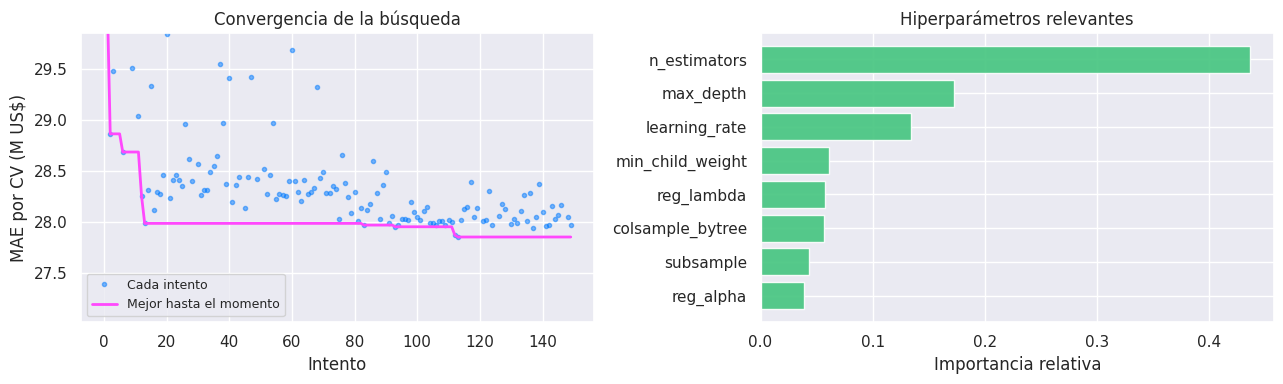

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

valores = np.array([t.value for t in estudio.trials if t.value is not None]) / 1e6
axes[0].plot(valores, "o", ms=3, alpha=0.5, color=AZUL, label="Cada intento")
axes[0].plot(np.minimum.accumulate(valores), lw=2, color=MAGENTA,
             label="Mejor hasta el momento")
axes[0].set_xlabel("Intento")
axes[0].set_ylabel("MAE por CV (M US$)")
axes[0].set_ylim(valores.min() * 0.97, np.percentile(valores, 90))
axes[0].set_title("Convergencia de la búsqueda")
axes[0].legend(fontsize=9)

importancia_hp = optuna.importance.get_param_importances(estudio)
nombres = list(importancia_hp)[::-1]
axes[1].barh(nombres, [importancia_hp[n] for n in nombres], color=VERDE, alpha=0.9)
axes[1].set_xlabel("Importancia relativa")
axes[1].set_title("Hiperparámetros relevantes")

plt.tight_layout()
plt.show()

### 9.3 Comparativa final

Comparamos todos los modelos contra el baseline. Todos los modelos se evaluan sobre el mismo conjunto de testeo que no participó de ninguna búsqueda.

In [ ]:
resultados_ajustados = [evaluar(f"{nombre} (ajustado)", est)
                        for nombre, est in ajustados.items()]

final = pd.DataFrame(baselines + resultados + resultados_ajustados).set_index("modelo")
final.round(3)

,MAE train [M US$],MAE CV [M US$],MAE test [M US$],RMSE [M US$],MedAPE,MAE log10,R2
modelo,,,,,,,
Modelo baseline,42.324,42.353,43.340,125.504,0.721,0.594,0.372
Ridge,32.698,32.978,33.481,96.918,0.632,0.516,0.626
SVR (RBF),20.540,29.665,29.221,86.120,0.566,0.453,0.704
KNN (k=15),0.000,35.592,35.529,105.550,0.647,0.523,0.556
Árbol de regresion,29.437,33.068,34.141,96.204,0.670,0.534,0.631
Random Forest,14.558,28.964,30.395,89.232,0.589,0.474,0.683
XGBoost,22.558,28.333,28.809,86.371,0.574,0.469,0.703
Ridge (ajustado),32.693,32.973,33.478,96.924,0.632,0.516,0.626
KNN (k=15) (ajustado),0.000,34.281,34.290,102.312,0.632,0.521,0.583


In [ ]:
estilo = (final
          .style
          .format({"MAE train [M US$]": "{:.1f}", "MAE CV [M US$]": "{:.1f}",
                   "MAE test [M US$]": "{:.1f}", "RMSE [M US$]": "{:.1f}",
                   "MedAPE": "{:.2f}", "MAE log10": "{:.3f}", "R2": "{:.3f}"})
          .background_gradient(subset=["MAE test [M US$]", "MAE log10"],
                               cmap="RdYlGn_r")
          .background_gradient(subset=["R2"], cmap="RdYlGn"))
estilo

,MAE train [M US$],MAE CV [M US$],MAE test [M US$],RMSE [M US$],MedAPE,MAE log10,R2
modelo,,,,,,,
Modelo baseline,42.3,42.4,43.3,125.5,0.72,0.594,0.372
Ridge,32.7,33.0,33.5,96.9,0.63,0.516,0.626
SVR (RBF),20.5,29.7,29.2,86.1,0.57,0.453,0.704
KNN (k=15),0.0,35.6,35.5,105.5,0.65,0.523,0.556
Árbol de regresion,29.4,33.1,34.1,96.2,0.67,0.534,0.631
Random Forest,14.6,29.0,30.4,89.2,0.59,0.474,0.683
XGBoost,22.6,28.3,28.8,86.4,0.57,0.469,0.703
Ridge (ajustado),32.7,33.0,33.5,96.9,0.63,0.516,0.626
KNN (k=15) (ajustado),0.0,34.3,34.3,102.3,0.63,0.521,0.583


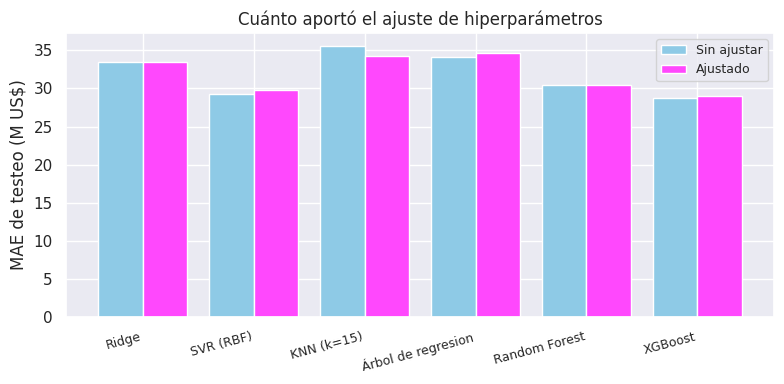

,sin ajustar,ajustado,mejora,% mejora
Ridge,33.481,33.478,0.003,0.008
SVR (RBF),29.221,29.825,-0.604,-2.067
KNN (k=15),35.529,34.290,1.240,3.489
Árbol de regresion,34.141,34.622,-0.481,-1.408
Random Forest,30.395,30.450,-0.056,-0.183
XGBoost,28.809,28.958,-0.149,-0.516


In [ ]:
# Cuánto le ganó a cada modelo su propio ajuste
antes = {f["modelo"]: f["MAE test [M US$]"] for f in resultados}
despues = {f["modelo"].replace(" (ajustado)", ""): f["MAE test [M US$]"]
           for f in resultados_ajustados}

efecto = pd.DataFrame({
    "sin ajustar": antes, "ajustado": despues,
}).assign(mejora=lambda d: d["sin ajustar"] - d["ajustado"],
          **{"% mejora": lambda d: (d["sin ajustar"] - d["ajustado"])
             / d["sin ajustar"] * 100})

fig, ax = plt.subplots(figsize=(8, 4))
pos = np.arange(len(efecto))
ax.bar(pos - 0.2, efecto["sin ajustar"], 0.4, label="Sin ajustar", color=CELESTE)
ax.bar(pos + 0.2, efecto["ajustado"], 0.4, label="Ajustado", color=MAGENTA)
ax.set_xticks(pos)
ax.set_xticklabels(efecto.index, rotation=15, ha="right", fontsize=9)
ax.set_ylabel("MAE de testeo (M US$)")
ax.set_title("Cuánto aportó el ajuste de hiperparámetros")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

efecto.round(3)

Dos lecturas sobre el efecto del ajuste.

**Es chico comparado con la elección del modelo.** La distancia entre familias (un lineal contra un ensamble de árboles) es de varios millones de dólares de MAE; lo que agrega optimizar los
hiperparámetros de cada uno es un orden de magnitud menor. Dicho de otro modo: **elegir bien el
modelo importa mucho más que afinarlo**, y conviene gastar el esfuerzo en ese orden.

**Y puede ser negativo en testeo.** Las búsquedas optimizan el MAE por **validación cruzada**, que es
lo correcto, pero eso no garantiza mejorar en testeo. Si algún modelo ajustado queda apenas por
detrás del que no lo está, la lectura no es "el ajuste lo empeoró" sino que **la diferencia está
dentro del ruido**: con unas dos mil películas de testeo, unos pocos cientos de miles de dólares de
MAE no se distinguen de la variabilidad del muestreo.

Conviene tenerlo presente cada vez que se ordena una tabla de modelos: **el orden de las últimas
posiciones casi nunca es significativo**. Para afirmar que un modelo es mejor que otro hace falta que
la diferencia supere su propio error de estimación, no que aparezca más arriba en la tabla.

### 9.4 El modelo final

Nos quedamos con el mejor de la tabla y estudiamos cómo se distribuyen sus errores y de qué
variables depende.

In [ ]:
# `evaluar` dejó entrenados todos los estimadores del diccionario
nombre_mejor = final["MAE test [M US$]"].idxmin()
mejor = ajustados.get(nombre_mejor.replace(" (ajustado)", ""),
                      estimadores.get(nombre_mejor))
print(f"Mejor modelo por MAE de testeo: {nombre_mejor}")

y_pred_mejor = mejor.predict(X_test)
y_pred_base = estimadores["Múltiplo del presupuesto"].predict(X_test)

Mejor modelo por MAE de testeo: XGBoost (ajustado)


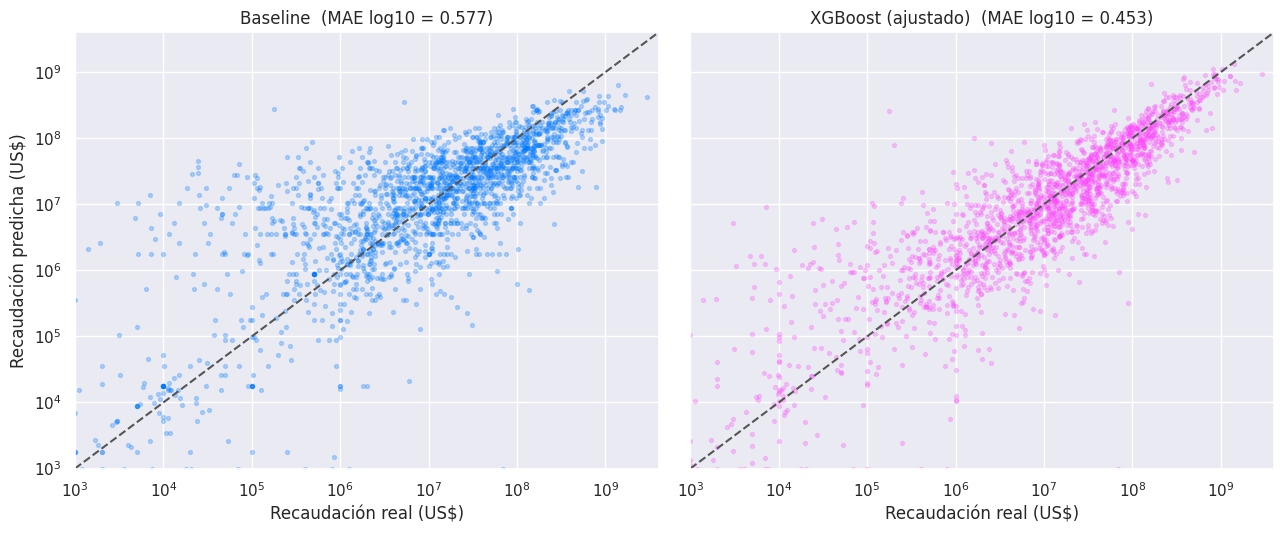

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True, sharey=True)
lim = [1e3, 4e9]

for ax, pred, titulo, color in [
    (axes[0], y_pred_base, "Baseline", AZUL),
    (axes[1], y_pred_mejor, nombre_mejor, MAGENTA),
]:
    ax.scatter(y_test, np.clip(pred, 1e3, None), s=8, alpha=0.25, color=color)
    ax.plot(lim, lim, color=GRIS, ls="--", lw=1.5)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.set_xlabel("Recaudación real (US$)")
    ax.set_title(f"{titulo}  (MAE log10 = {mae_log10(y_test, pred):.3f})")

axes[0].set_ylabel("Recaudación predicha (US$)")
plt.tight_layout()
plt.show()

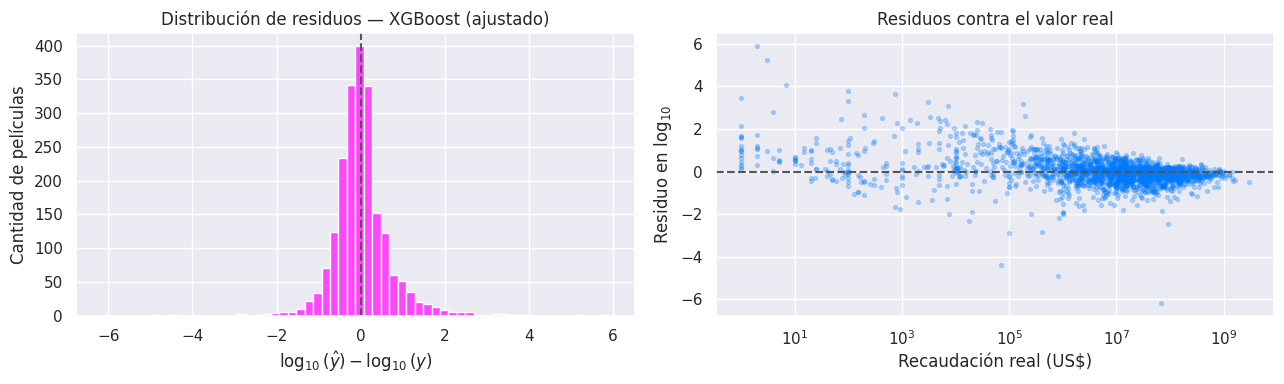

Residuo mediano: -0.036 órdenes de magnitud
Predicciones dentro de un factor 2 del valor real: 50.8%


In [ ]:
residuos = np.log10(np.clip(y_pred_mejor, 1, None)) - np.log10(np.clip(y_test, 1, None))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(residuos, bins=60, color=MAGENTA, edgecolor="white")
axes[0].axvline(0, color=GRIS, ls="--", lw=1.5)
axes[0].set_xlabel("$\\log_{10}(\\hat{y}) - \\log_{10}(y)$")
axes[0].set_ylabel("Cantidad de películas")
axes[0].set_title(f"Distribución de residuos — {nombre_mejor}")

axes[1].scatter(y_test, residuos, s=8, alpha=0.25, color=AZUL)
axes[1].axhline(0, color=GRIS, ls="--", lw=1.5)
axes[1].set_xscale("log")
axes[1].set_xlabel("Recaudación real (US$)")
axes[1].set_ylabel("Residuo en $\\log_{10}$")
axes[1].set_title("Residuos contra el valor real")

plt.tight_layout()
plt.show()

print(f"Residuo mediano: {np.median(residuos):+.3f} órdenes de magnitud")
print(f"Predicciones dentro de un factor 2 del valor real: "
      f"{(np.abs(residuos) < np.log10(2)).mean():.1%}")

El gráfico de residuos contra el valor real muestra el patrón típico de un modelo entrenado en
escala logarítmica sobre datos muy dispersos: **sobreestima las películas de recaudación baja y
subestima las de recaudación muy alta**, es decir, regresa hacia la media. Es esperable y es el
precio de optimizar el error en logaritmos.

#### Importancia de las variables

Usamos `permutation_importance` sobre el conjunto de testeo: mide cuánto empeora el MAE al permutar
al azar cada columna. A diferencia de la importancia interna de los árboles, no está sesgada hacia
las variables de alta cardinalidad y se calcula sobre datos que el modelo no vio.

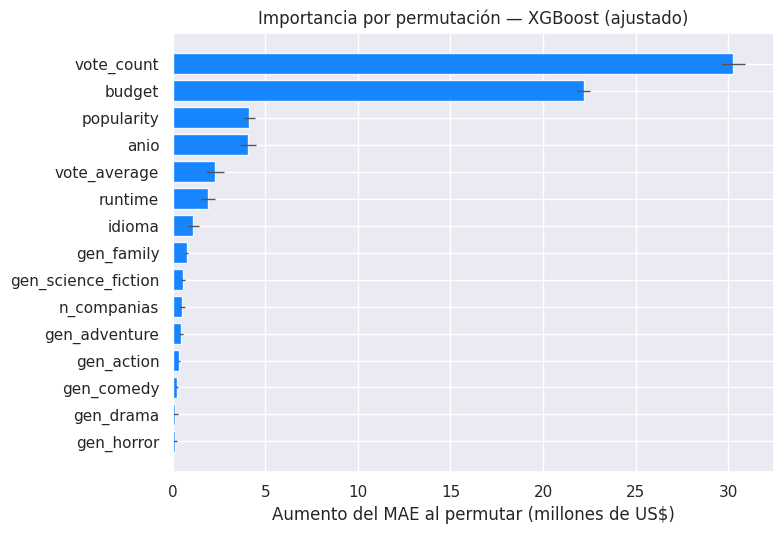

In [ ]:
importancias = permutation_importance(
    mejor, X_test, y_test, n_repeats=10,
    scoring="neg_mean_absolute_error",
    random_state=RANDOM_STATE, n_jobs=-1,
)

medias = pd.Series(importancias.importances_mean, index=X_test.columns)
desvios = pd.Series(importancias.importances_std, index=X_test.columns)

ranking = medias.sort_values(ascending=False).head(15) / 1e6
errores = desvios[ranking.index] / 1e6

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(ranking.index[::-1], ranking.values[::-1], xerr=errores.values[::-1],
        color=AZUL, alpha=0.9, error_kw={"ecolor": GRIS, "lw": 1})
ax.set_xlabel("Aumento del MAE al permutar (millones de US$)")
ax.set_title(f"Importancia por permutación — {nombre_mejor}")
plt.tight_layout()
plt.show()

---
## 10. Conclusiones

**Sobre los datos.** El dataset original tiene cerca de 1.4 millones de películas, pero apenas una
fracción mínima trae presupuesto y recaudación cargados. El trabajo real del EDA no fue encontrar
correlaciones sino **descubrir que el 0 es un `NaN` disfrazado** y aceptar el costo de quedarnos con
un dataset dos órdenes de magnitud más chico. Un modelo entrenado sobre el crudo habría aprendido,
sobre todo, a predecir cero.

Al filtrar el dataset y quedarnos con datos validos (`revenue` & `budget` > 0) nuestra muesta queda significativamente reducida. Resaltamos que ante un futuro trabajo, antes de probar con modelos mas potentes o realizar busqueda exhaustiva de hiper-parametros, conviene empezar con agrandar la muestra de peliculas validas integrando otras fuentes de datos.

**Sobre el target.** La recaudación abarca nueve órdenes de magnitud. Modelar directamente en
dólares hace que la función de pérdida quede dominada por un puñado de *blockbusters*; pasar a
escala logarítmica es lo que vuelve tratable el problema. Reportar el MAE en dólares **y** en
$\log_{10}$ evita sacar conclusiones equivocadas a partir de una sola métrica.

**Sobre las métricas.** En este trabajo las cinco métricas terminan ordenando a los modelos de la misma manera, pero cuentan historias distintas sobre qué tan bueno es el mejor modelo. Un $R^2$ de 0,72 suena a un ajuste sólido, y sin embargo el MedAPE del mismo modelo es 0,59: para la mitad de las películas de testeo la predicción se equivoca por más del 59% del valor real. No es una contradicción, es que miden cosas distintas: el $R^2$ compara contra la varianza total de un target que abarca nueve órdenes de magnitud y está dominado por los *blockbusters*, mientras que el MedAPE describe el error típico de una película cualquiera. Con un target así de disperso, quedarse con una sola métrica cuenta solo una parte de la historia, y por eso reportamos varias en paralelo.

**Sobre los modelos.** La brecha grande está entre *no usar información* y *usar el presupuesto*;
la brecha entre un modelo lineal en logaritmos y uno de árboles es real pero mucho más chica. Eso
dice algo del fenómeno: la relación presupuesto → recaudación es aproximadamente una **ley de
potencias**, y lo que agregan los modelos no lineales es corregirla según género, idioma, época y
recepción del público.

**Sobre las *features*.** El conjunto quedó deliberadamente chico: presupuesto, popularidad, votos,
duración, año, idioma, cantidad de productoras y los doce géneros principales. Varias variables fueron descartadas, ya que al conocer el dominio del problema, sabiamos que no eran features relavantes para nuestro problema de regresion.

**Limitaciones y caminos siguientes:**

- **Sesgo de selección.** El modelo vale para películas con distribución comercial, no para el
  catálogo completo de TMDB. Cualquier extrapolación fuera de ese universo es injustificada.
- **Variables posteriores al estreno.** `popularity`, `vote_count` y `vote_average` no están
  disponibles antes del estreno. Un experimento valioso es reentrenar **sin ellas** para medir el
  desempeño en el escenario de decisión real (¿financiar o no?), que es bastante más difícil.
- **Validación temporal.** Partimos train/test al azar. Para un uso realista corresponde un corte
  cronológico (entrenar con estrenos anteriores a cierto año y testear con los posteriores) que
  además evita filtrar información del futuro.
- **Inflación.** Los montos son nominales: 100 millones de 1990 no son 100 millones de 2023.
  Deflactar `revenue` y `budget` con el **CPI-U** (*Consumer Price Index for All Urban Consumers*,
  el índice de precios al consumidor de Estados Unidos) expresaría todos los montos en dólares de un
  mismo año de referencia y los volvería comparables entre épocas.
- **Features sin explotar.** `keywords`, `overview` y las productoras admiten representaciones más
  ricas (TF-IDF, *target encoding* de los estudios grandes) que quedaron fuera de este trabajo.